In [1]:
pip install langchain_community

  Using cached langchain_community-0.4.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached aiohttp-3.14.1-cp311-cp311-win_amd64.whl.metadata (8.5 kB)
  Using cached httpx_sse-0.4.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached langchain_classic-1.0.8-py3-none-any.whl.metadata (5.1 kB)
  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached pydantic_settings-2.14.2-py3-none-any.whl.metadata (3.4 kB)
  Using cached sqlalchemy-2.0.51-cp311-cp311-win_amd64.whl.metadata (9.8 kB)
  Using cached aiohappyeyeballs-2.6.2-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached frozenlist-1.8.0-cp311-cp311-win_amd64.whl.metadata (21 kB)
  Using cached multidict-6.7.1-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached propcache-0.5.2-cp311-cp311-win_amd64.whl.metadata (17 kB)
  Using cached yarl-1.24.2-cp311-cp311-win_amd64.whl.metadata


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install ddgs

  Using cached ddgs-9.14.4-py3-none-any.whl.metadata (20 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached primp-1.3.1-cp310-abi3-win_amd64.whl.metadata (3.8 kB)
  Using cached lxml-6.1.1-cp311-cp311-win_amd64.whl.metadata (3.6 kB)
  Using cached fake_useragent-2.2.0-py3-none-any.whl.metadata (17 kB)
  Using cached brotli-1.2.0-cp311-cp311-win_amd64.whl.metadata (6.3 kB)
  Using cached h2-4.3.0-py3-none-any.whl.metadata (5.1 kB)
  Using cached socksio-1.0.0-py3-none-any.whl.metadata (6.1 kB)
  Using cached hyperframe-6.1.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached hpack-4.2.0-py3-none-any.whl.metadata (3.3 kB)
Using cached ddgs-9.14.4-py3-none-any.whl (70 kB)
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached fake_useragent-2.2.0-py3-none-any.whl (161 kB)
Using cached socksio-1.0.0-py3-none-any.whl (12 kB)
Using cached lxml-6.1.1-cp311-cp311-win_amd64.whl (4.0 MB)
Using cached primp-1.3.1-cp310-abi3-win_amd64.whl (4.7 MB)
Using cached


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq 
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random


C:\Users\maaz7\AppData\Local\Temp\ipykernel_25304\1705252499.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [4]:
search_tool= DuckDuckGoSearchRun(region="us-en")

@tool
def calculate(first_num: float, second_num: float, operation: str)-> dict:
    """
    Perform basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation=="add":
            result=first_num+second_num
        elif operation=="sub":
            result= first_num-second_num
        elif operation=="mul":
            result=first_num*second_num
        elif operation=="div":
            if second_num==0:
                return {'error':"Division by zero is not allowed"}
            result=first_num/second_num
        else:
            return {'error':f"Unsupported operation'{operation}'"}
        
        return {'first_num':first_num,"second_num": second_num,
                "operation":operation,"result":result}
    except Exception as e:
        return {"error": str(e)}

@tool
def get_stock_price(symbol: str)->dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL','TSLA')
    using Alpha Vantage with API key in the URL.

    """
    
    url=f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=QROOLY4I9404L2WQ"
    r= requests.get(url)
    return r.json()

In [5]:
tools=[get_stock_price, search_tool, calculate]
llm_with_tools = llm.bind_tools(tools)


In [6]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [7]:
def chat_node(state: ChatState):
    """LLM node that may answer my question or request a tool call"""
    messages = state['messages']
    res = llm_with_tools.invoke(messages)
    return {'messages':[res]}

tool_node = ToolNode(tools)

In [11]:
graph=StateGraph(ChatState)

graph.add_node("chat_node",chat_node)
graph.add_node("tools",tool_node)


In [12]:
graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node",tools_condition)
graph.add_edge("tools","chat_node")

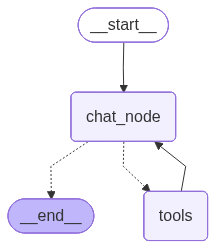

In [13]:
chatbot=graph.compile()
chatbot

In [36]:
out = chatbot.invoke({'messages':[HumanMessage(content="Hello")]})
print(out["messages"][-1].content)

Hello! How can I assist you today?


In [15]:
out = chatbot.invoke({'messages':[HumanMessage(content="What is the procuct of 2*3")]})
print(out["messages"][-1].content)

The product of 2 × 3 is 6.


In [16]:
out = chatbot.invoke({'messages':[HumanMessage(content="What is the stock price of apple")]})
print(out["messages"][-1].content)

Apple (AAPL) is currently trading at **$289.36 per share** (price as of the latest trading day, 2026‑06‑30).


In [17]:
out = chatbot.invoke({'messages':[HumanMessage(content="What is the stock pprice of Tesla. How much 50 shares of tesla costs")]})
print(out["messages"][-1].content) 

- **Current Tesla (TSLA) stock price:** **$420.60** per share (as of the close on 2026‑06‑30).  
- **Cost for 50 shares:** 50 × $420.60 = **$21,030.00**.  

So buying 50 shares of Tesla at today’s price would cost about **$21,030**.
